In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

In [130]:
df = pd.read_csv(r'C:\Users\am216\Downloads\fraudTest.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [101]:
df.describe ()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [91]:
df.info

<bound method DataFrame.info of         Unnamed: 0 trans_date_trans_time            cc_num  \
0                0   2020-06-21 12:14:25  2291163933867244   
1                1   2020-06-21 12:14:33  3573030041201292   
2                2   2020-06-21 12:14:53  3598215285024754   
3                3   2020-06-21 12:15:15  3591919803438423   
4                4   2020-06-21 12:15:17  3526826139003047   
...            ...                   ...               ...   
555714      555714   2020-12-31 23:59:07    30560609640617   
555715      555715   2020-12-31 23:59:09  3556613125071656   
555716      555716   2020-12-31 23:59:15  6011724471098086   
555717      555717   2020-12-31 23:59:24     4079773899158   
555718      555718   2020-12-31 23:59:34  4170689372027579   

                                    merchant        category     amt    first  \
0                      fraud_Kirlin and Sons   personal_care    2.86     Jeff   
1                       fraud_Sporer-Keebler   personal_care 

In [92]:
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [131]:
df.drop(columns = "Unnamed: 0",inplace = True)

In [103]:
df["dob"] = pd.to_datetime(df["dob"])

In [104]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)


# EDA

In [10]:
df["is_fraud"].value_counts()

0    553574
1      2145
Name: is_fraud, dtype: int64

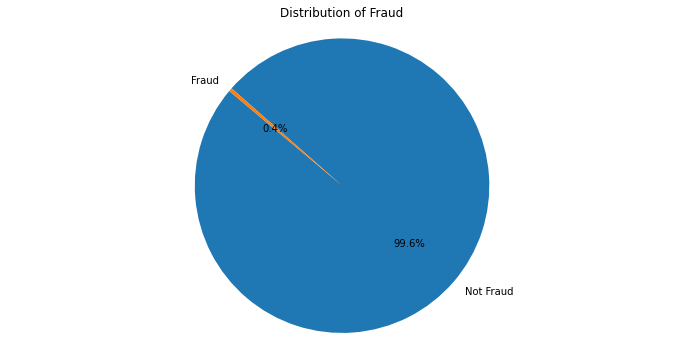

In [9]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = df.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

<AxesSubplot:xlabel='is_fraud'>

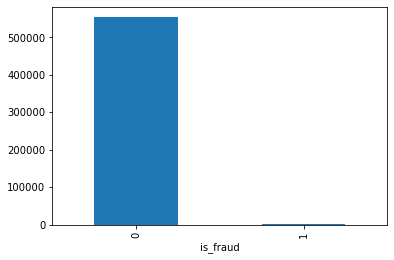

In [12]:
df.groupby("is_fraud").count()["cc_num"].plot(kind = "bar")

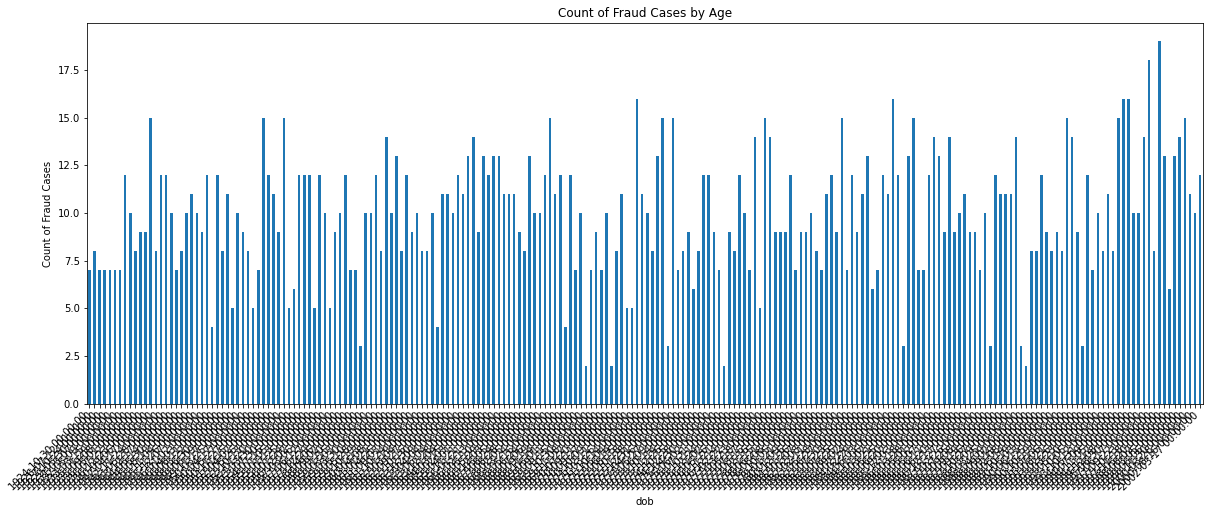

In [15]:
plt.figure(figsize=(20, 7))
ax = df[df['is_fraud'] == 1].groupby('dob').count()['is_fraud'].plot(kind='bar')
ax.set_xlabel('dob')
ax.set_ylabel('Count of Fraud Cases')
ax.set_title('Count of Fraud Cases by Age')
plt.xticks(rotation=45, ha='right')
plt.show()

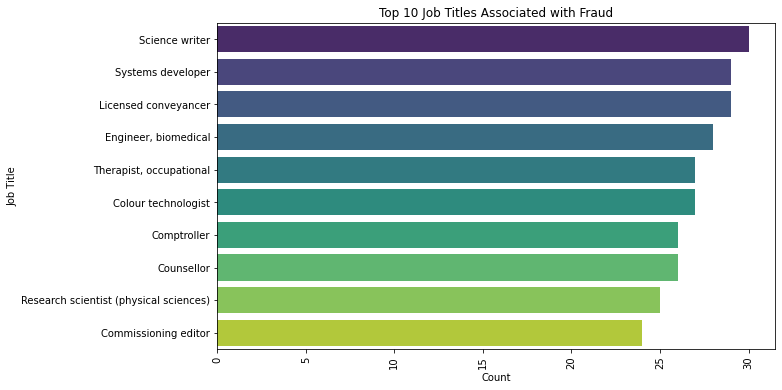

In [17]:
# Extract top 10 job titles associated with fraud and their counts
fraud_job_title = df[df["is_fraud"] == 1]["job"].value_counts().head(10)


# Convert to a DataFrame for easier plotting
fraud_job_title_df = fraud_job_title.reset_index()
fraud_job_title_df.columns = ['job', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_job_title_df, x="count", y="job",palette="viridis",dodge=False)
plt.title('Top 10 Job Titles Associated with Fraud')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.xticks(rotation=90)
plt.show()

In [18]:
df["category"].value_counts()

gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: category, dtype: int64

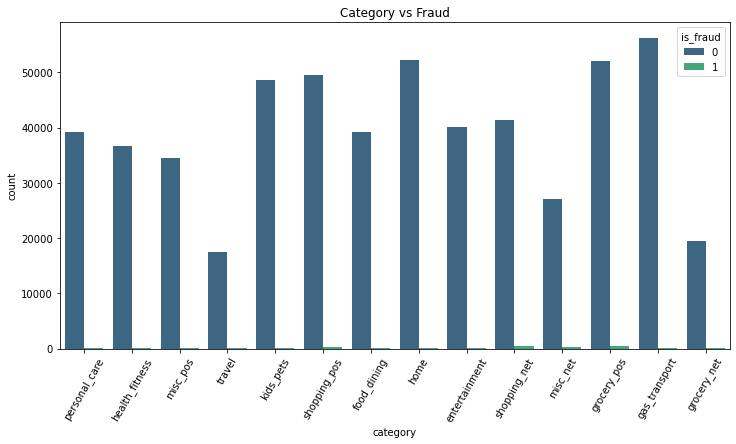

In [19]:
plt.figure(figsize = (12,6))
sns.countplot(x = "category",hue = "is_fraud",data = df,palette = "viridis")
plt.title("Category vs Fraud")
plt.xticks(rotation = 60)
plt.show()

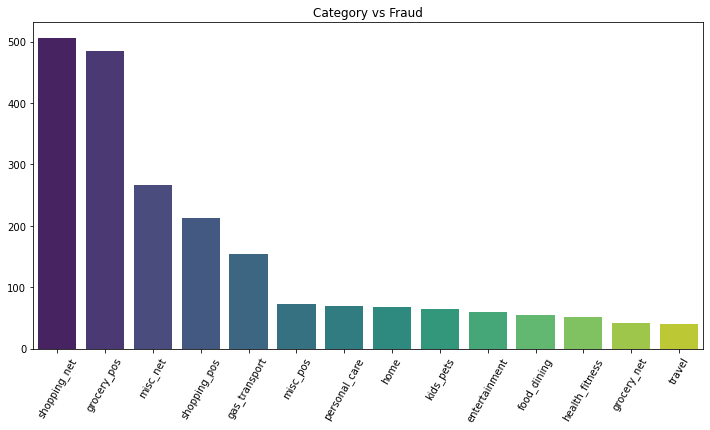

In [21]:
plt.figure(figsize = (12,6))
fraud_category = df[df["is_fraud"] == 1]["category"].value_counts()
sns.barplot(x = fraud_category.index,y = fraud_category.values, palette = "viridis")
plt.title("Category vs Fraud")
plt.xticks(rotation = 60)
plt.show()

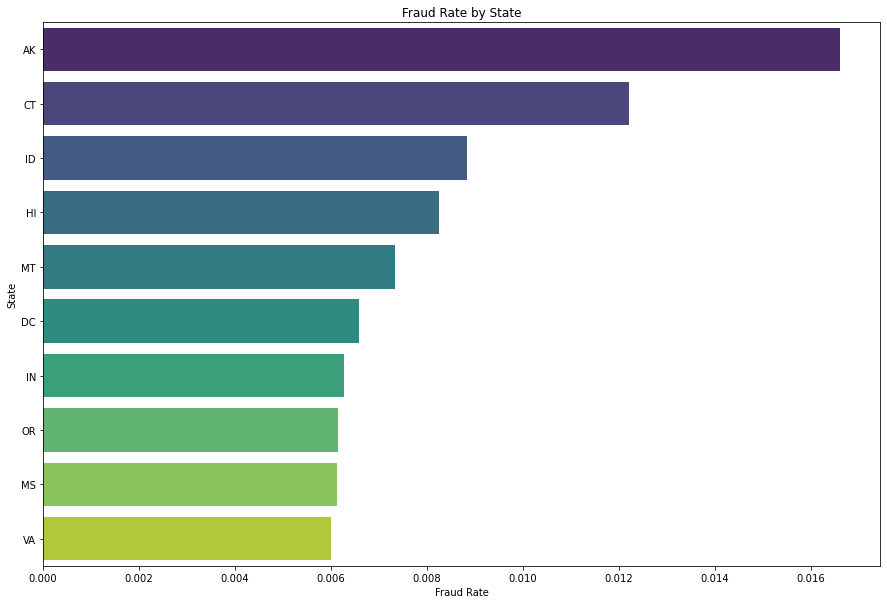

In [22]:
fraud_rate_by_state = df.groupby('state')['is_fraud'].mean().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(15, 10))
sns.barplot(data=fraud_rate_by_state, x='is_fraud', y='state', palette='viridis')
plt.title('Fraud Rate by State')
plt.xlabel('Fraud Rate')
plt.ylabel('State')
plt.show()

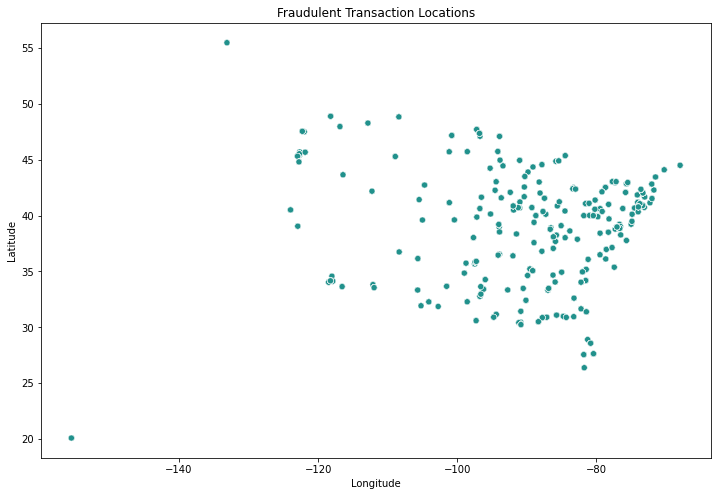

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df[df['is_fraud'] == 1], x='long', y='lat', hue='is_fraud', palette='viridis', legend=False)
plt.title('Fraudulent Transaction Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [132]:
numeric_columns = [i for i in df.columns if df[i].dtype == 'int64' or df[i].dtype =='int32' or df[i].dtype =='float64']
categorical_columns = [i for i in df.columns if df[i].dtype == 'object']

In [133]:
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2291163933867244,319,10,2.86,151,115,1,341,157,...,33.9659,-80.9355,333497,275,376,98699,1371816865,33.986391,-81.200714,0
1,1,3573030041201292,591,10,29.84,163,457,0,354,16,...,40.3207,-110.4360,302,392,760,108785,1371816873,39.450498,-109.960431,0
2,2,3598215285024754,611,5,41.28,24,249,0,865,61,...,40.6729,-73.5365,34496,259,421,433979,1371816893,40.495810,-74.196111,0
3,3,3591919803438423,222,9,60.05,42,457,1,320,764,...,28.5697,-80.8191,54767,407,718,71993,1371816915,28.812398,-80.883061,0
4,4,3526826139003047,292,13,3.19,247,261,1,548,247,...,44.2529,-85.0170,1126,196,177,190585,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,544755,30560609640617,507,5,43.77,235,315,1,531,443,...,40.4931,-91.8912,519,460,334,336391,1388534347,39.946837,-91.333331,0
555715,544756,3556613125071656,264,7,111.84,171,424,1,540,401,...,29.0393,-95.4401,28739,198,890,70372,1388534349,29.661049,-96.186633,0
555716,544757,6011724471098086,496,7,86.88,18,239,0,126,104,...,46.1966,-118.9017,3684,294,609,235088,1388534355,46.658340,-119.715054,0
555717,544758,4079773899158,75,13,7.99,111,342,1,663,476,...,44.6255,-116.4493,129,58,331,43546,1388534364,44.470525,-117.080888,0


In [113]:
from sklearn.preprocessing import MinMaxScaler
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print(df.head())

   trans_date_trans_time    cc_num  merchant  category       amt  first  last  \
0                      0  0.000459       319        10  0.000082    151   115   
1                      1  0.000716       591        10  0.001267    163   457   
2                      2  0.000721       611         5  0.001769     24   249   
3                      3  0.000719       222         9  0.002594     42   457   
4                      4  0.000706       292        13  0.000096    247   261   

   street  city  state  ...      long  city_pop  job        dob  trans_num  \
0     341   157     39  ...  0.867121  0.114727  275 1968-03-19      98699   
1     354    16     43  ...  0.565239  0.000096  392 1990-01-17     108785   
2     865    61     33  ...  0.942836  0.011860  259 1970-10-21     433979   
3     320   764      8  ...  0.868312  0.018834  407 1987-07-25      71993   
4     548   247     21  ...  0.825355  0.000379  196 1955-07-06     190585   

      unix_time  merch_lat  merch_long  is_f

In [114]:
categorical_features = df.select_dtypes(include=['object']).columns
#Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Print the dataframe with label encoded columns
print(df.head())

   trans_date_trans_time    cc_num  merchant  category       amt  first  last  \
0                      0  0.000459       319        10  0.000082    151   115   
1                      1  0.000716       591        10  0.001267    163   457   
2                      2  0.000721       611         5  0.001769     24   249   
3                      3  0.000719       222         9  0.002594     42   457   
4                      4  0.000706       292        13  0.000096    247   261   

   street  city  state  ...      long  city_pop  job        dob  trans_num  \
0     341   157     39  ...  0.867121  0.114727  275 1968-03-19      98699   
1     354    16     43  ...  0.565239  0.000096  392 1990-01-17     108785   
2     865    61     33  ...  0.942836  0.011860  259 1970-10-21     433979   
3     320   764      8  ...  0.868312  0.018834  407 1987-07-25      71993   
4     548   247     21  ...  0.825355  0.000379  196 1955-07-06     190585   

      unix_time  merch_lat  merch_long  is_f

In [139]:
columns = df.columns.tolist() 
columns.remove('is_fraud')

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']


scaler = StandardScaler()

X[columns] = scaler.fit_transform(X[columns])
df[X.columns] = X
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,is_fraud
0,-1.732669,-0.317252,-0.119663,0.961683,-0.424463,-0.232273,-0.994479,1.102494,-1.083619,0.937072,-0.731091,-0.904377,0.677451,0.816521,0.243860,-0.461769,-1.116803,-1.703871,0
1,-1.732663,-0.316273,1.231656,0.961683,-0.252337,-0.106449,1.568286,-0.907034,-1.659570,1.220424,1.309217,0.351182,-1.472454,-0.292685,1.102086,1.033750,-1.053931,-1.703869,0
2,-1.732656,-0.316254,1.331017,-0.316151,-0.179353,-1.563901,0.009646,-0.907034,-1.475756,0.512044,-1.382695,0.420768,1.216667,-0.178853,0.126496,-0.286513,0.973182,-1.703865,0
3,-1.732650,-0.316259,-0.601568,0.706116,-0.059605,-1.375166,1.568286,1.102494,1.395827,-1.258908,-0.598119,-1.970539,0.685934,-0.111371,1.212115,0.870177,-1.283276,-1.703861,0
4,-1.732644,-0.316308,-0.253802,1.728384,-0.422358,0.774312,0.099567,1.102494,-0.715991,-0.338013,0.029394,1.128092,0.380004,-0.289942,-0.335625,-1.236791,-0.544027,-1.703861,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,1.725931,-0.318978,0.814337,-0.316151,-0.163467,0.648489,0.504214,1.102494,0.084621,-0.196337,0.544041,0.385244,-0.120967,-0.291963,1.600884,-0.625342,0.364862,1.510350,0
555715,1.725937,-0.316286,-0.392908,0.194983,0.270803,-0.022567,1.321002,1.102494,-0.086939,1.149586,1.069562,-1.877757,-0.379599,-0.198018,-0.320955,1.540045,-1.293380,1.510351,0
555716,1.725944,-0.314411,0.759688,0.194983,0.111564,-1.626812,-0.065289,-0.907034,-1.300111,1.432939,1.879720,1.512121,-2.089408,-0.281427,0.383230,0.445668,-0.266615,1.510352,0
555717,1.725950,-0.318998,-1.331876,1.728384,-0.391735,-0.651683,0.706538,1.102494,0.219418,-0.975555,1.295849,1.201709,-1.910685,-0.293261,-1.347891,-0.637026,-1.460602,1.510354,0


In [126]:
X.head()

,category,amt,city,state,lat,long,city_pop,gender_M
0,10,0.000082,157,39,0.305255,0.867121,0.114727,1
1,10,0.001267,16,43,0.444423,0.565239,0.000096,0
2,5,0.001769,61,33,0.452136,0.942836,0.011860,0
3,9,0.002594,764,8,0.187080,0.868312,0.018834,1
4,13,0.000096,247,21,0.530537,0.825355,0.000379,1


In [127]:
y.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: is_fraud, dtype: float64

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [144]:
# Assuming X is a DataFrame with datetime columns
# Remove datetime columns if they are not needed for modeling
#X = X.drop(columns=['dob'])  # Corrected syntax: drop(columns=['column_name'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X, y)


RandomForestClassifier(max_depth=20, n_estimators=10, n_jobs=-1,
                       random_state=42)

In [145]:
y_pred = model_rfc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

Accuracy Score: 0.9994541615681758


In [153]:
gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )
# Fit to training set
gbc.fit(X, y)
 
# Predict on test set
pred_y = gbc.predict(X_test)
 

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Gradient Boosting Classifier accuracy is : {:.2f}".format(acc))

Gradient Boosting Classifier accuracy is : 1.00
